In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd
import json

import igl 
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

In [2]:
from src import utils 

import importlib
import src.fatemarkers
import src.meshharm

importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)
from src.fatemarkers import FateMarkers

In [ ]:
path = 'Data/20260211/'


with open(f"{path}/config.json", 'r') as f:
    cfg = json.load(f)
timepoints  = cfg['timepoints']
zarr_names  = cfg['zarr_names']
wells       = cfg['wells']
rounds      = cfg['rounds']
times_dic   = cfg['times_dic']

In [704]:
ts = np.exp(2*np.linspace(0, np.log(10), 20))

def load(save_path, ts): 
    m = FateMarkers()
    m.load_results(save_path)
    frac_diff = m.compute_recon_quality()
    
    _, _, _, _, new_indices = igl.decimate(m.v, m.f, 200) 
    hks = [] 
    for t in ts:
        x = np.einsum('i, ji->j', np.exp(-m.eigvals*t), m.eigvecs[new_indices, :]**2)
        hks.append(x) 
    hks = np.array(hks).T 

    c = complexity(m)
    return hks, frac_diff, c

def complexity(m, threshold=0.015): 
    for l in range(1, m.lmax+1): 
        err = m.compute_recon_quality(lmax=l)
        if err < threshold:
            return l
    return m.lmax

In [ ]:
hkss = [] 
times = [] 
fracs = [] 
ids = [] 
complexities = []

for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint]

        file_path = f"{path}/fractal_output/{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(f"{file_path}/fm_data/good_labels.npy")
        for label in tqdm(labels):
            save_path = f"{file_path}/fm_data/{label}"
            if os.path.exists(save_path + '_coeffs.npz'):
                hks, frac, c = load(save_path, ts=ts)
                hkss.append(hks)
                times.append(timepoint[3:])
                fracs.append(frac)
                ids.append(f"{timepoint}_{well_name}_{label}") 
                complexities.append(c)

 35%|███▍      | 27/78 [00:06<00:11,  4.37it/s]


KeyboardInterrupt: 

In [41]:
threshold = np.percentile(fracs, 95)
recon_mask = np.array(fracs) < threshold

# Convert boolean mask to indices array
recon_indices = np.where(recon_mask)[0]

# Convert to numpy arrays for set operations
ids_array = np.array(ids)
filtered_ids_array = np.array(ids_array[recon_mask])

# Find elements in ids that are not in filtered_ids
excluded_ids = np.setdiff1d(ids_array, filtered_ids_array)
print(f"IDs excluded by filtering: {len(excluded_ids)} out of {len(ids)} total")
print(f"excluded IDs: {excluded_ids}")

# filter using this mask 
filtered_complexities = np.array(complexities)[recon_mask]
filtered_hkss = [hkss[i] for i in recon_indices]
filtered_times = np.array(times)[recon_mask]
filtered_ids = np.array(ids)[recon_mask]


IDs excluded by filtering: 30 out of 584 total
excluded IDs: ['day2p5_A02_45' 'day3_A02_1' 'day3_A03_24' 'day3_A04_87' 'day3_A05_94'
 'day4_A04_16' 'day4_A04_82' 'day4_B01_25' 'day4_B02_45'
 'day4p5-more_C01_53' 'day4p5-more_C02_105' 'day4p5-more_C02_128'
 'day4p5-more_C02_77' 'day4p5-more_C03_110' 'day4p5-more_C03_14'
 'day4p5-more_C03_149' 'day4p5-more_C03_166' 'day4p5-more_C03_17'
 'day4p5-more_C03_30' 'day4p5-more_C03_64' 'day4p5-more_C03_97'
 'day4p5-more_C04_11' 'day4p5-more_C04_132' 'day4p5-more_C04_80'
 'day4p5-more_C04_87' 'day4p5-more_C04_96' 'day4p5-more_C05_152'
 'day4p5-more_C05_42' 'day4p5-more_C05_67' 'day4p5-more_C05_82']


In [42]:
# draw evenly from complexities
complexity_intervals = [(2, 3), (4, 4), (5, 6)]
no_per_group = [np.sum((filtered_complexities >= interval[0]) & (filtered_complexities <= interval[1])) for interval in complexity_intervals] 
samples_per_group = int(np.min(no_per_group))

selected_indices = []
for interval in complexity_intervals:
    group_indices = np.where((filtered_complexities >= interval[0]) & (filtered_complexities <= interval[1]))[0]
    selected_indices.extend(np.random.choice(group_indices, size=samples_per_group, replace=False)) 

filtered_times = filtered_times[selected_indices]
filtered_ids = filtered_ids[selected_indices]

In [406]:
# rescale hks by the sum over a single timepoint across one organoid 

def normalise(hks): 
    mean_rm = hks/np.mean(hks, axis=0, keepdims=True) - 1 
    return (mean_rm)

normalised_filtered_hks = [normalise(filtered_hkss[i]) for i in selected_indices]

In [407]:
# Apply indices to filter hkss list
collected_hks = np.concatenate(normalised_filtered_hks)
print(collected_hks.shape)

np.savez('sim/bof_raw_value.npz', 
         filtered_ids=filtered_ids,
         filtered_times=filtered_times,
         filtered_hks=collected_hks, 
         hks_per_organoid = [len(hkss) for hkss in filtered_hkss]
)

(12240, 20)


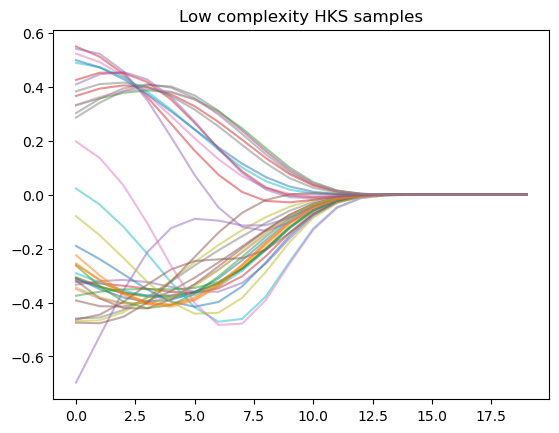

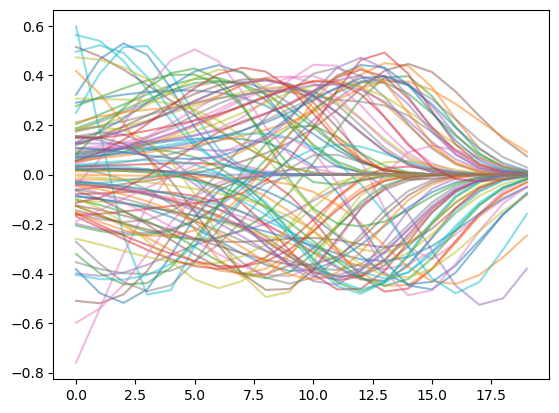

In [538]:
from sklearn.preprocessing import StandardScaler, Normalizer
scaler = Normalizer()
rescaled_hks = scaler.fit_transform(collected_hks)


low_complexity_indices = np.where(filtered_complexities[selected_indices] <= 2)[0]

for i in low_complexity_indices: 
    plt.plot(rescaled_hks[i], alpha=0.5)
plt.title('Low complexity HKS samples')
plt.show() 


import random



random_indices = [random.randint(0, len(rescaled_hks)-1) for _ in range(100)]

for i in random_indices: 
    plt.plot(rescaled_hks[i], alpha=0.5)
plt.show() 

In [7]:
data = np.load('sim/bof_raw_value.npz')
filtered_times = data['filtered_times']
filtered_ids = data['filtered_ids']
collected_hks = data['filtered_hks']

(12240, 8)


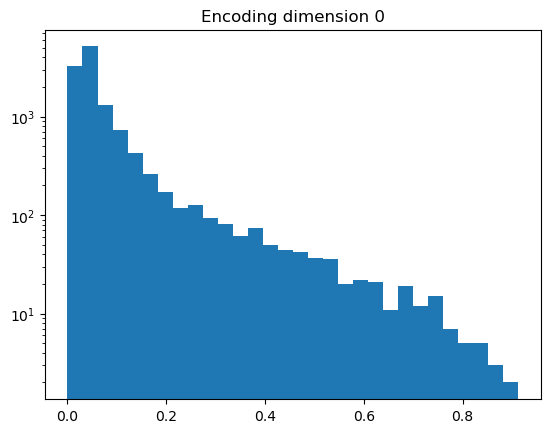

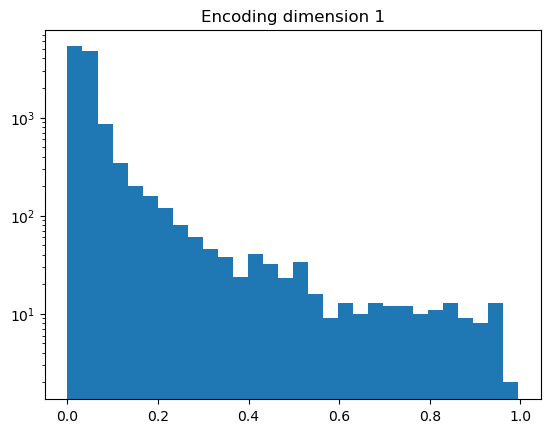

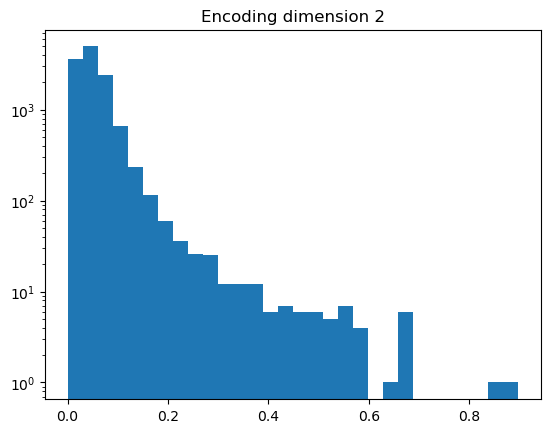

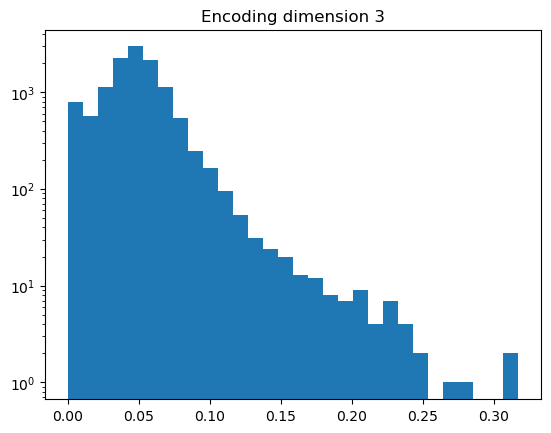

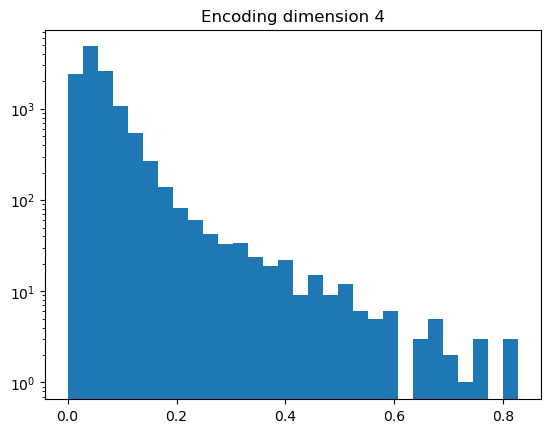

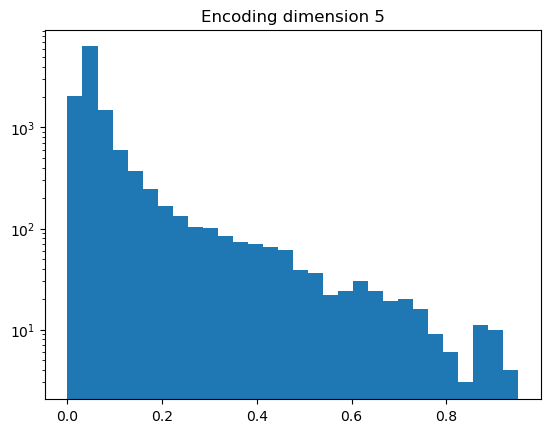

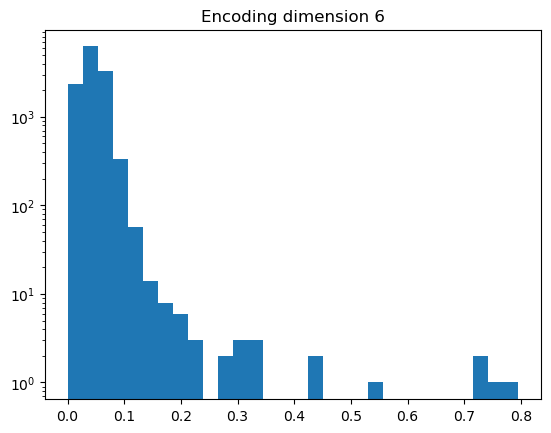

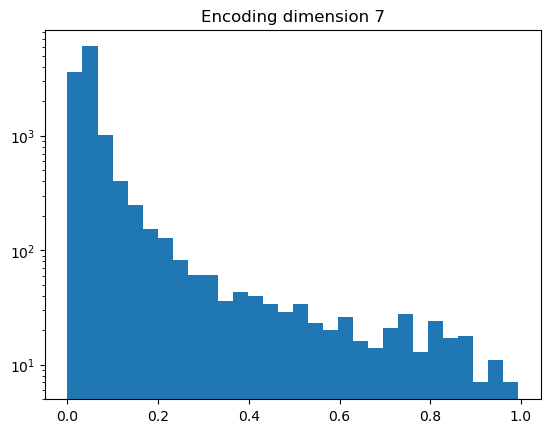

In [13]:
res = np.load('sim/vocab_new.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scaler'].item() 
sigma = res['sigma']
ts = res['ts']

encodings = np.linalg.norm(collected_hks[:, np.newaxis, :]- vocab[np.newaxis, :, :], axis=2)
encodings = np.exp(-encodings**2/(2*sigma**2))

print(encodings.shape)

for i in range(encodings.shape[1]):
    plt.title(f'Encoding dimension {i}')
    plt.hist(encodings[:, i], bins=30)
    plt.yscale('log')
    plt.show() 

In [410]:
curvature_mask = np.abs((rescaled_hks[:, 0] - np.mean(rescaled_hks[:, 0]))/np.std(rescaled_hks[:, 0])) < 4   # select points with curvature feature within [-2, 2]
filtered_rescaled_hks = rescaled_hks[curvature_mask]

In [484]:
from sklearn.cluster import KMeans, HDBSCAN, AgglomerativeClustering
from sklearn.manifold import MDS, TSNE 
from sklearn.decomposition import PCA

dim_reducer = PCA(n_components=2)
hks_2d = dim_reducer.fit_transform(filtered_rescaled_hks)

In [512]:
from sklearn.cluster import KMeans
cluster = KMeans(n_clusters=8, random_state=42)
cluster.fit(filtered_rescaled_hks)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


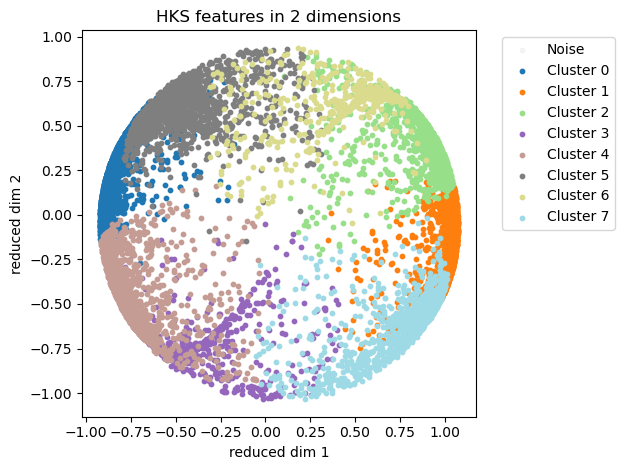

In [513]:
import matplotlib.cm as cm
colors = cm.tab20(np.linspace(0, 1, len(np.unique(cluster.labels_))))
plt.scatter(hks_2d[cluster.labels_==-1, 0], hks_2d[cluster.labels_==-1, 1], 
            s=10, label='Noise', alpha=0.2, c='lightgrey')
for i in range(0, cluster.labels_.max() + 1):
    plt.scatter(hks_2d[cluster.labels_==i, 0], hks_2d[cluster.labels_==i, 1], 
                s=10, label=f'Cluster {i}', alpha=1, c=[colors[i]])
plt.xlabel('reduced dim 1')
plt.ylabel('reduced dim 2')
plt.title('HKS features in 2 dimensions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

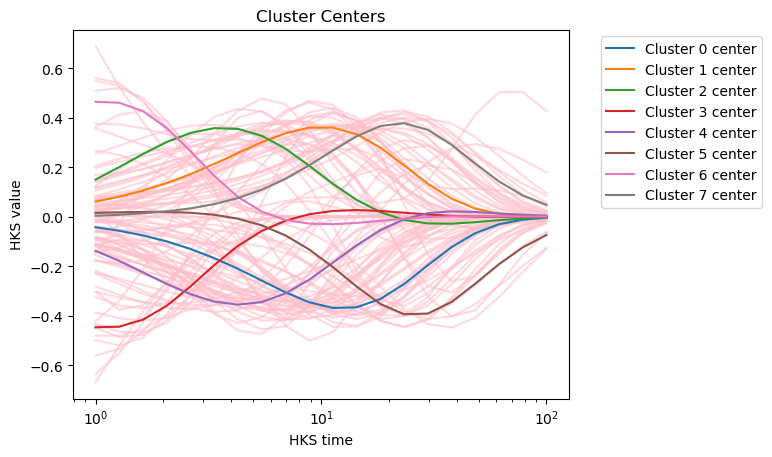

In [517]:
# plot the center of each cluster
import random
random_indices = [random.randint(0, len(collected_hks)-1) for _ in range(100)]

for i in random_indices: 
    plt.plot(ts, rescaled_hks[i], color='pink', alpha=0.6)

cluster_centers = [] 
colors = plt.cm.tab20(np.linspace(0, 1, cluster.labels_.max() + 1))
for i in range(cluster.labels_.max() + 1):
    center = filtered_rescaled_hks[cluster.labels_==i].mean(axis=0)
    cluster_centers.append(center)  
    plt.plot(ts, center, '-', label=f'Cluster {i} center')
# plt.ylim([0, 0.08])
plt.xscale('log')
plt.xlabel('HKS time')
plt.ylabel('HKS value')
plt.title('Cluster Centers')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [515]:
cluster_id = cluster.labels_

# compute distance to the nearest cluster center 
dist = np.zeros(filtered_rescaled_hks.shape[0])
for i in range(cluster.labels_.max() + 1):
    m = (cluster_id == i)
    center = cluster_centers[i].reshape(1,-1)
    d = np.linalg.norm(filtered_rescaled_hks[m] - center, axis=1)
    dist[m] = d

sigma = np.sqrt(np.mean(dist**2))
print("Sigma:", sigma)

vocab = np.array(cluster_centers)

Sigma: 0.37496661745918547


In [516]:
np.savez('sim/vocab_new.npz', vocab=vocab, scaler=scaler, ts=ts, sigma=sigma)

In [ ]:
res = np.load('sim/vocab_new.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scaler'].item() 
sigma = res['sigma']
ts = res['ts']

In [470]:
min_ids = [] 
for (n, v) in enumerate(vocab): 
    min_d = np.inf 
    mind_index = -1 
    for i in range(len(normalised_filtered_hks)):
        rescaled_hks_i = scaler.transform(normalised_filtered_hks[i])
        new_d = np.min(np.linalg.norm(rescaled_hks_i - v[np.newaxis, :], axis=1))
        if new_d < min_d:
            min_d = new_d
            mind_index = i
    min_ids.append(filtered_ids[mind_index])
    print(f"Closest to vocab vector {n}: {filtered_ids[mind_index]} with distance {min_d}")

print(min_ids)

Closest to vocab vector 0: day2_A03_69 with distance 0.08869504928588867
Closest to vocab vector 1: day4p5-more_C03_47 with distance 0.08445422351360321
Closest to vocab vector 2: day4_A02_65 with distance 0.09382908046245575
Closest to vocab vector 3: day4_A02_51 with distance 0.048115745186805725
Closest to vocab vector 4: day4_A06_6 with distance 0.09136730432510376
Closest to vocab vector 5: day3p5_A02_102 with distance 0.047091249376535416
Closest to vocab vector 6: day2p5_A05_62 with distance 0.0783911794424057
Closest to vocab vector 7: day4p5-more_C02_93 with distance 0.10898134112358093
Closest to vocab vector 8: day4p5-more_C01_120 with distance 0.04507545381784439
Closest to vocab vector 9: day3p5_B03_3 with distance 0.062307920306921005
['day2_A03_69', 'day4p5-more_C03_47', 'day4_A02_65', 'day4_A02_51', 'day4_A06_6', 'day3p5_A02_102', 'day2p5_A05_62', 'day4p5-more_C02_93', 'day4p5-more_C01_120', 'day3p5_B03_3']


In [594]:
bof_spectrums = [] 
areas = [] 
complexities2 = []
for id in tqdm(np.array(ids)[recon_mask]):
     timepoint, well_name, label = id.split('_')
     zarr_name = zarr_names[timepoint]
     round_name = rounds[timepoint][0]
     file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/fm_data/{label}"
     m = FateMarkers()
     m.load_results(file_path) 
     hks = m.compute_hks_for_new_times(ts, coeffs=False)

     hks = hks / np.mean(hks, axis=0) - 1 
     rescaled = scaler.transform(hks)
     dist = np.linalg.norm(rescaled[:, np.newaxis, :]- vocab[np.newaxis, :, :], axis=2)
     encoding = np.exp(-dist**2/(2*sigma**2))

     coeffs_hks = m.eigvecs.T @ (m.mass_matrix @ encoding)
     s = m.compute_spectrum(coeffs_hks, lmax=5)
     bof_spectrums.append(np.sqrt(s)/np.sqrt(m.mass_matrix.diagonal().sum()))
     areas.append(m.mass_matrix.diagonal().sum())
     complexities2.append(complexity(m))


100%|██████████| 554/554 [00:46<00:00, 11.80it/s]


(554, 5, 8)


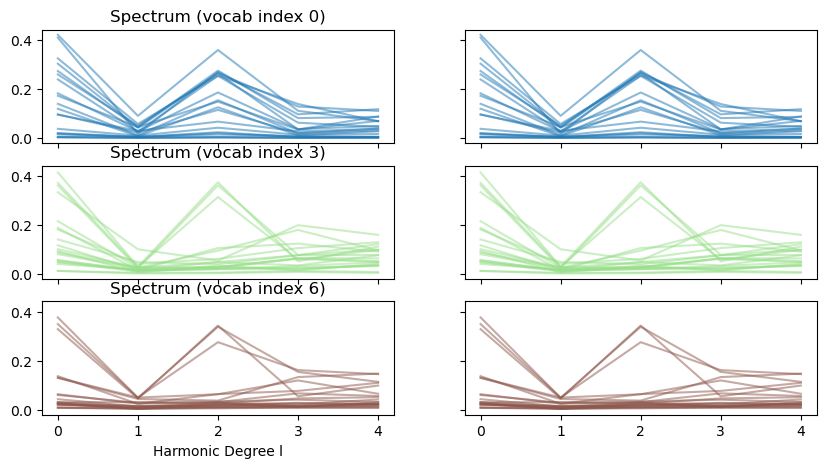

In [689]:
bof_spectrums = np.array(bof_spectrums)
bof_scaled = np.copy(np.array(bof_spectrums)+1e-5)
print(bof_spectrums.shape)

fig, axes = plt.subplots(3, 2, figsize=(10, 5), sharex=True, sharey=True)

colors = plt.cm.tab20(np.linspace(0, 1, bof_spectrums.shape[1]))
random_indices = [random.randint(0, bof_spectrums.shape[0]-1) for _ in range(20)]
for (k, vocab_index) in enumerate([0, 3, 6]): 
    for j in random_indices:
        axes[k, 0].plot(bof_spectrums[j, :, vocab_index], color=colors[k], alpha=0.5)
        axes[k, 1].plot(bof_scaled[j, :, vocab_index], color=colors[k], alpha=0.5)
    axes[k, 0].set_title(f"Spectrum (vocab index {vocab_index})")  

axes[-1, 0].set_xlabel('Harmonic Degree l')

plt.show()

In [696]:
# Reshape the bag-of-features spectrums for feature selection
bof_spectrums_reshaped = bof_scaled.reshape(bof_spectrums.shape[0], -1)

bof_spectrums_scaled = Normalizer().fit_transform(bof_spectrums_reshaped)
# bof_spectrums_scaled = np.copy(bof_spectrums_reshaped) 

In [697]:
n_clusters = 8
kmeans_spectrums = KMeans(n_clusters=n_clusters)
kmeans_spectrums.fit(bof_spectrums_scaled)

cluster_id = kmeans_spectrums.labels_
spectrum_cluster_centers = [] 
for i in range(n_clusters):
    center = bof_spectrums_scaled[cluster_id == i].mean(axis=0).reshape(1,-1)
    spectrum_cluster_centers.append(center.flatten())


from sklearn.manifold import MDS, TSNE 
mds = TSNE(n_components=2) #, random_state=42, perplexity=30)

to_fit = np.concatenate((bof_spectrums_scaled, np.array(spectrum_cluster_centers)), axis=0)
mds.fit(to_fit)
reduced_dim_rep = mds.fit_transform(to_fit)

spectrum_pcs = reduced_dim_rep[:bof_spectrums_scaled.shape[0], :]
cluster_pcs = reduced_dim_rep[bof_spectrums_scaled.shape[0]:, :]

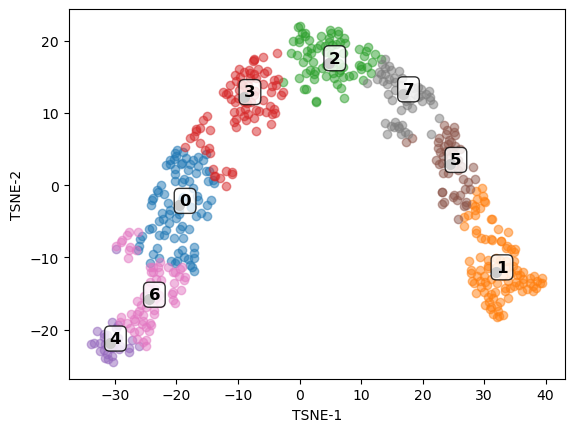

In [698]:


for id in range(n_clusters): 
    mask = (cluster_id == id)
    plt.plot(spectrum_pcs[mask, 0], spectrum_pcs[mask, 1], 'o', alpha=0.5)

plt.plot(cluster_pcs[:, 0], cluster_pcs[:, 1], 'o', markersize=7, color='black')

for i in range(len(cluster_pcs)): 
    plt.text(cluster_pcs[i, 0], cluster_pcs[i, 1], 
             str(i), fontsize=12, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black', alpha=0.8))

plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.show()

['1p5' '2' '2p5' '3' '3p5' '4' '4p5' '4p5-more']


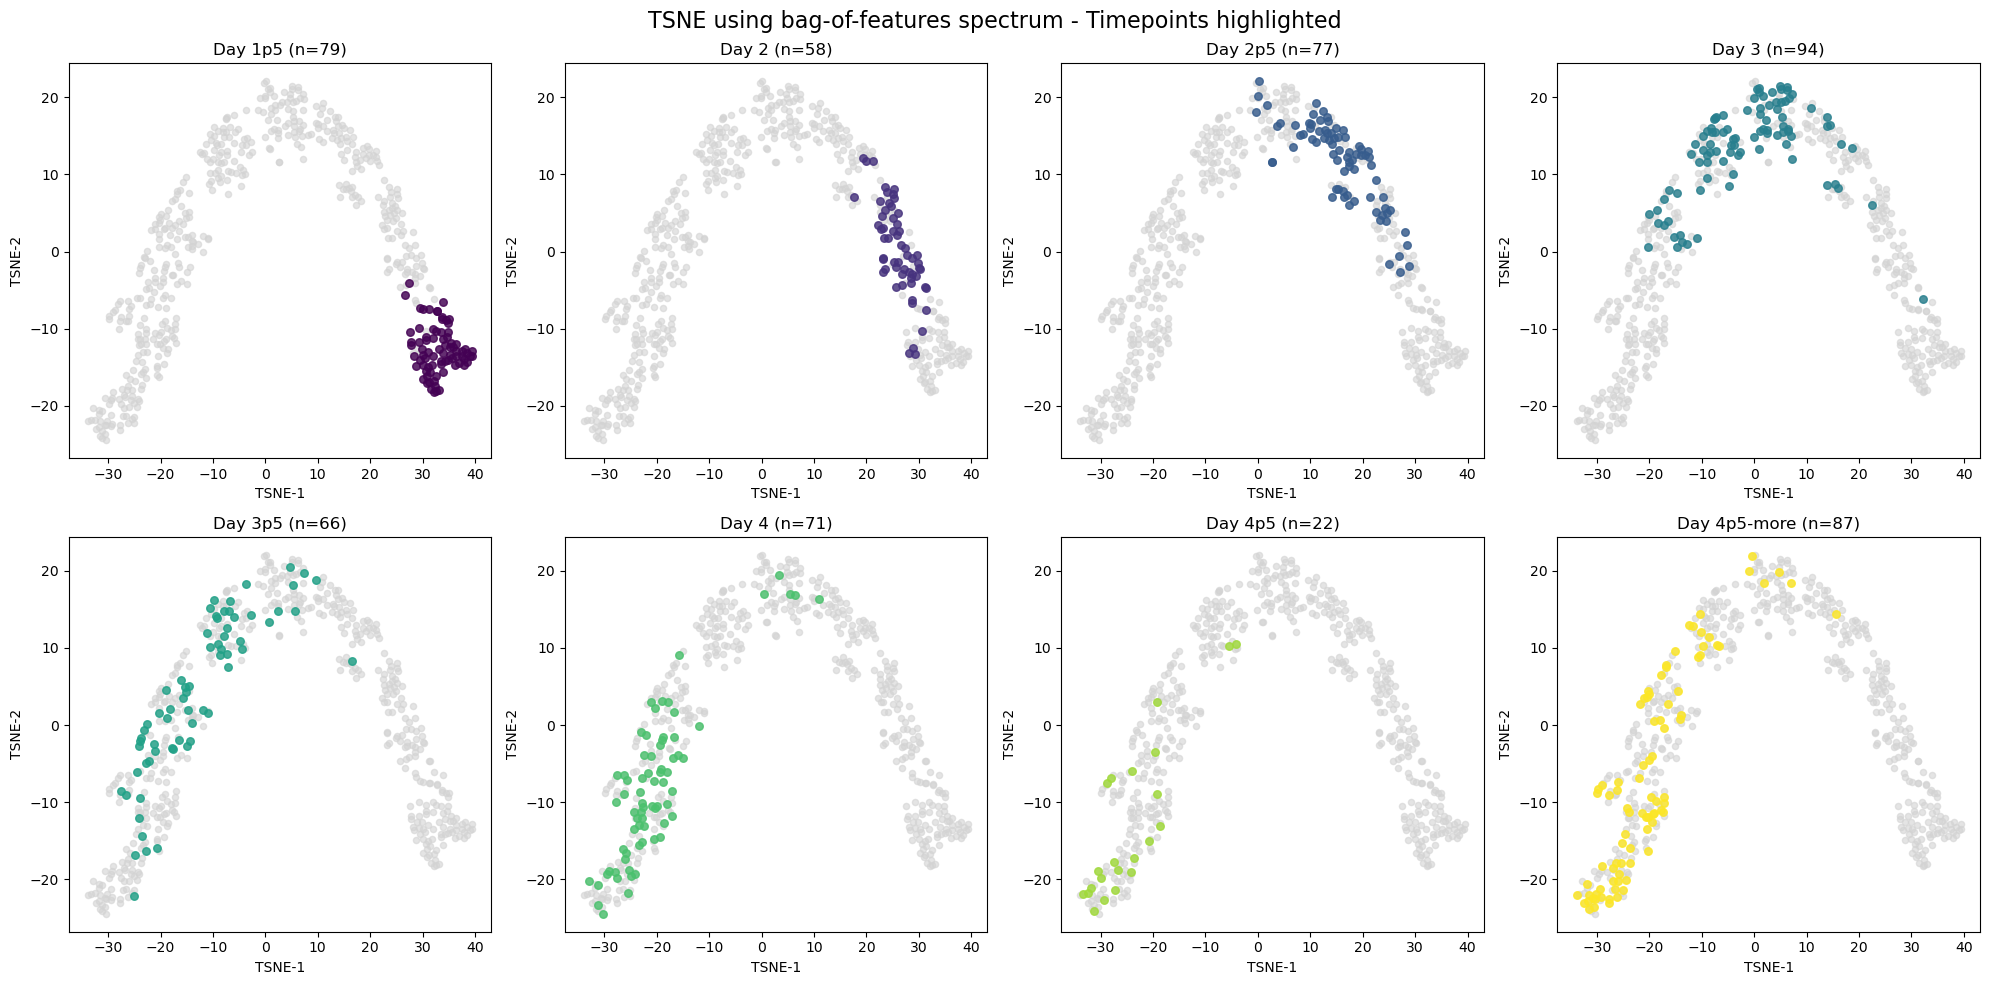

In [699]:
# Create subplots for each timepoint - spectrum PCA

full_times = np.array(times)[recon_mask]

unique_times = np.unique(full_times)

print(unique_times)
# Use a continuous colormap that represents time progression
cmap = plt.cm.viridis  # You can also try 'plasma', 'inferno', 'magma', 'cool', 'warm'
colors = [cmap(i / (len(unique_times) - 1)) for i in range(len(unique_times))]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, time in enumerate(unique_times):
    ax = axes[i]
    
    # Plot all points in light gray
    ax.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], 
              c='lightgray', alpha=0.6, s=20)
    
    # Highlight current timepoint with color from continuous map
    times_mask = (full_times == time)
    ax.scatter(spectrum_pcs[:, 0][times_mask], spectrum_pcs[:, 1][times_mask], 
              c=[colors[i]], alpha=0.8, s=30, label=f'Day {time}')

    ax.set_xlabel('TSNE-1')
    ax.set_ylabel('TSNE-2')
    ax.set_title(f'Day {time} (n={np.sum(times_mask)})')

plt.suptitle('TSNE using bag-of-features spectrum - Timepoints highlighted', fontsize=16)
plt.tight_layout()
plt.show()

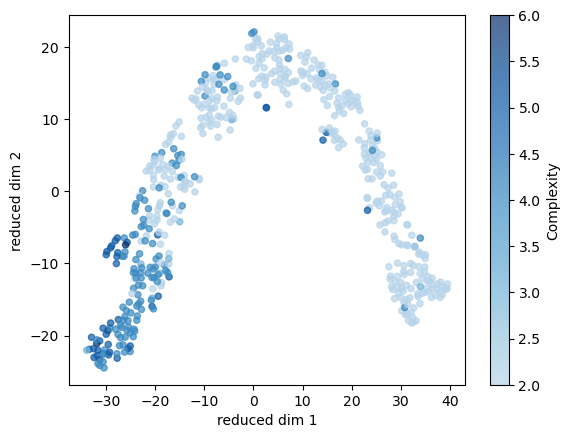

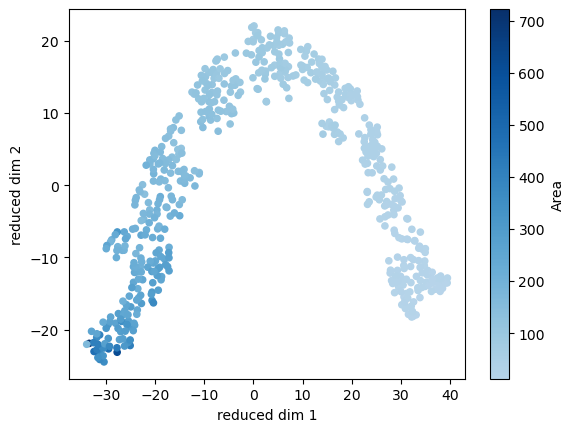

In [700]:
cmap = plt.get_cmap('Blues')

# Use only the darker portion of Blues colormap (50% to 100%)
colors = cmap(np.linspace(0.3, 1.0, 256))
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(colors)


plt.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], c=np.array(complexities2), s=20, alpha=0.7, cmap=custom_cmap)
plt.colorbar(label='Complexity')
plt.xlabel('reduced dim 1')
plt.ylabel('reduced dim 2')
plt.show()

plt.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], c=areas, s=20, cmap=custom_cmap)
plt.colorbar(label='Area')
plt.xlabel('reduced dim 1')
plt.ylabel('reduced dim 2')
plt.show() 

In [643]:
print(bof_spectrums.shape) 
print(bof_spectrums_scaled.shape)

(554, 5, 8)
(554, 40)


(554, 5, 8)


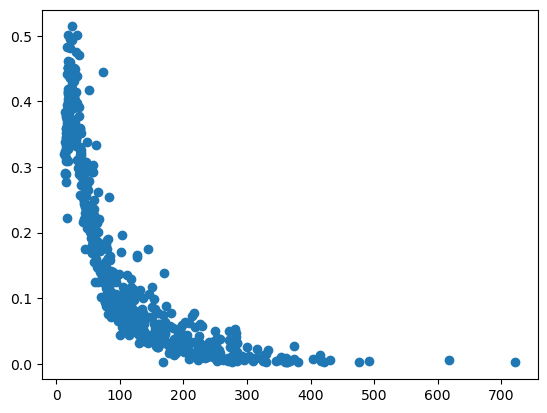

In [649]:
print(bof_spectrums.shape) 

plt.plot(areas, bof_spectrums[:, 0, 3], 'o')
plt.show() 

In [242]:
dist = kmeans_spectrums.transform(bof_spectrums_scaled)

# Find the closest point to each cluster center
cluster_center_ids = filtered_ids[np.argmin(dist, axis=0)[[2, 3, 0, 1, 4]]]

print(cluster_center_ids) 

['day1p5_A06_82' 'day2p5_A06_71' 'day2_A02_80' 'day3p5_A04_47'
 'day1p5_A03_146']


In [120]:
from meshplot import plot

for i, id in enumerate(cluster_center_ids): 
    timepoint, well_name, label = id.split('_')
    zarr_name = zarr_names[timepoint]
    round_name = rounds[timepoint][0]
    file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/fm_data/{label}"
    m = FateMarkers()
    m.load_results(file_path) 

    coeffs_hks = m.compute_hks_for_new_times(new_ts=[4])
    hks = m.reconstruct_from_coeffs(coeffs_hks[:])
    
    # Create the meshplot visualization
    print(np.min(hks[:, -1]), np.max(hks[:, -1]))
    plot(m.v, m.f, c=hks[:, -1])

0.05750586 0.057869926


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0117599…

0.022003373 0.023960292


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0137827…

0.014601862 0.040923275


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1062960…

0.030581867 0.03343963


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0506701…

0.020907886 0.026500573


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.126284…